# App de Diagnóstico Asistido — Clasificación de Biopsias de Mama

**MAI 540 — Machine Learning | Módulo 3**

Esta aplicación estima, a partir de mediciones tomadas de una biopsia por imagen, si un tumor es **maligno** o **benigno**. La idea es que el modelo ayude a priorizar qué casos revisa primero un especialista — la decisión final siempre es humana.

Dataset: *Wisconsin Breast Cancer* (incluido en `scikit-learn`), usado aquí con fines educativos.

---

**Esta aplicación no la escribiste tú.** Fue entregada por otra persona del equipo y necesita salir a producción esta semana. Antes de tocar una sola línea, tu trabajo es entenderla: qué hace cada función, cómo fluyen los datos de una celda a la siguiente, y qué pasa cuando la ejecutas de principio a fin.

Ejecuta todo el notebook, en orden, tal como está.

El código no tiene errores de sintaxis: corre sin problema hasta que la lógica falla. Los defectos son de comportamiento, no de escritura — no pierdas tiempo buscando un paréntesis o una coma fuera de lugar.

## Cómo trabajar con Claude Code en este ejercicio

Ya llevas dos módulos usando Claude Code — no arranques con instrucciones vagas como si fuera la primera semana. Aplica lo mismo que ya usaste en la Tarea 2.1 con tu propio dataset:

1. **Pide que lea antes de que toque nada.** Que te explique qué hace cada función y cómo fluyen los datos entre celdas, antes de autorizar un cambio.
2. **Formula tú la hipótesis, no se la pidas hecha.** Dile qué crees que está pasando y pídele que lo verifique — no preguntes directamente "¿por qué falla esto?".
3. **Verifica lo que decide por su cuenta.** Igual que revisaste tu propia columna prohibida en la Tarea 2.1, revisa aquí cada columna que el modelo usa: ¿existiría en el momento real de predecir?
4. **La métrica va antes que el cambio.** `diagnostico` está desbalanceado. No aceptes una corrección solo porque el número subió; compara antes/después sobre la misma partición.

Nada nuevo en *cómo* usar la herramienta. Lo nuevo esta semana es *sobre qué* la usas: este código no lo escribiste tú, pero ayudarás a resolver por qué no funciona.

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score

RANDOM_STATE = 42
rng = np.random.RandomState(RANDOM_STATE)

## 1. Carga de datos

Cargamos el dataset base y lo enriquecemos con dos columnas que el equipo clínico pidió agregar:

- `num_biopsias_previas`: cuántas biopsias se le habían hecho antes a la paciente.
- `sesiones_tratamiento_programadas`: cuántas sesiones de tratamiento tiene ya programadas la paciente.

In [2]:
def cargar_datos():
    """Carga el dataset de biopsias y agrega las columnas clínicas complementarias."""
    data = load_breast_cancer(as_frame=True)
    df = data.frame.copy()
    df['diagnostico'] = data.target  # 0 = maligno, 1 = benigno
    n = len(df)

    df['num_biopsias_previas'] = rng.randint(0, 4, size=n)
    df['sesiones_tratamiento_programadas'] = np.where(
        df['diagnostico'] == 0,
        rng.randint(3, 9, size=n),
        0,
    )
    return df


df = cargar_datos()
df[['mean texture', 'mean smoothness', 'num_biopsias_previas',
    'sesiones_tratamiento_programadas', 'diagnostico']]

     mean texture  ...  diagnostico
0           10.38  ...            0
1           17.77  ...            0
2           21.25  ...            0
3           20.38  ...            0
4           14.34  ...            0
..            ...  ...          ...
564         22.39  ...            0
565         28.25  ...            0
566         28.08  ...            0
567         29.33  ...            0
568         24.54  ...            1

[569 rows x 5 columns]

## 2. Exploración inicial

Antes de modificar nada, conviene entender qué llegó: cuántos casos hay, cómo se distribuye el diagnóstico, y si hay datos faltantes.

In [3]:
def explorar_datos(df):
    """Imprime un resumen rápido del dataset antes de entrenar nada."""
    print(f"Filas: {len(df)}  |  Columnas: {df.shape[1]}")
    print()
    print("Distribución de diagnóstico (0 = maligno, 1 = benigno):")
    print(df['diagnostico'].value_counts(normalize=True).round(3))
    print()
    print("Valores nulos por columna (solo columnas con al menos 1):")
    nulos = df.isna().sum()
    print(nulos[nulos > 0] if nulos.any() else "Ninguno")


explorar_datos(df)

Filas: 569  |  Columnas: 34

Distribución de diagnóstico (0 = maligno, 1 = benigno):
diagnostico
1    0.627
0    0.373
Name: proportion, dtype: float64

Valores nulos por columna (solo columnas con al menos 1):
Ninguno


### Gráficas de exploración

Dos vistas rápidas: cómo se distribuye la clase objetivo, y cómo se correlaciona cada columna numérica con el diagnóstico.

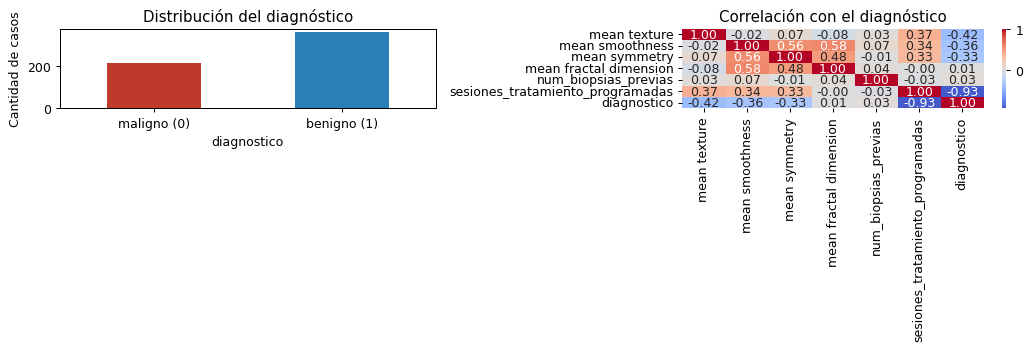

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['diagnostico'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#c0392b', '#2980b9']
)
axes[0].set_xticklabels(['maligno (0)', 'benigno (1)'], rotation=0)
axes[0].set_title('Distribución del diagnóstico')
axes[0].set_ylabel('Cantidad de casos')

columnas_para_correlacion = [
    'mean texture', 'mean smoothness', 'mean symmetry', 'mean fractal dimension',
    'num_biopsias_previas', 'sesiones_tratamiento_programadas', 'diagnostico',
]
corr = df[columnas_para_correlacion].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Correlación con el diagnóstico')

plt.tight_layout()
plt.show()

## 3. Validación de calidad de datos

Un chequeo simple antes de entrenar: que no haya valores infinitos ni nulos colándose en las columnas numéricas.

In [5]:
def validar_datos(df, columnas):
    """Revisa que las columnas indicadas no tengan nulos ni valores infinitos."""
    problemas = {}
    for col in columnas:
        n_nulos = df[col].isna().sum()
        n_infinitos = np.isinf(df[col]).sum() if np.issubdtype(df[col].dtype, np.number) else 0
        if n_nulos or n_infinitos:
            problemas[col] = {'nulos': int(n_nulos), 'infinitos': int(n_infinitos)}
    return problemas


## 4. Ingeniería de características

A partir de la textura promedio y del número de biopsias previas, construimos un indicador de variabilidad por biopsia — mientras más biopsias previas tenga la paciente, más se "diluye" la variabilidad reportada.

In [6]:
def construir_caracteristicas(df):
    """Agrega una métrica derivada de variabilidad de textura por biopsia previa.

    Si la paciente no tiene biopsias previas (0) no hay nada que "diluir": se usa
    el divisor mínimo 1, de modo que la métrica queda igual a la textura promedio
    en lugar de dividir entre cero (que producía inf).
    """
    df = df.copy()
    df['variabilidad_por_biopsia'] = df['mean texture'] / df['num_biopsias_previas'].clip(lower=1)
    return df


df_features = construir_caracteristicas(df)
df_features[['mean texture', 'num_biopsias_previas', 'variabilidad_por_biopsia']].head(10)

   mean texture  num_biopsias_previas  variabilidad_por_biopsia
0         10.38                     2                  5.190000
1         17.77                     3                  5.923333
2         21.25                     0                 21.250000
3         20.38                     2                 10.190000
4         14.34                     2                  7.170000
5         15.70                     3                  5.233333
6         19.98                     0                 19.980000
7         20.83                     0                 20.830000
8         21.82                     2                 10.910000
9         24.04                     1                 24.040000

### Distribución de la característica nueva

Así se ve la variable recién construida. Vale la pena revisar si su forma tiene sentido.

Valores no finitos (inf/NaN) en la columna: 0 de 569


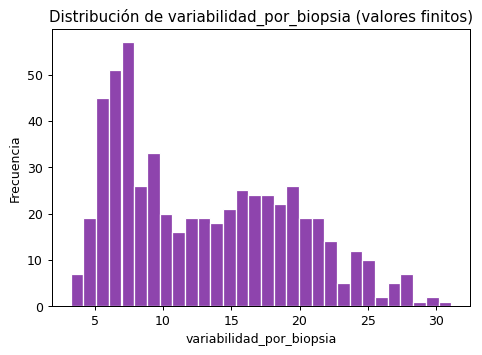

In [7]:
valores_finitos = df_features['variabilidad_por_biopsia'].replace([np.inf, -np.inf], np.nan)

plt.figure(figsize=(6, 4))
plt.hist(valores_finitos.dropna(), bins=30, color='#8e44ad', edgecolor='white')
plt.title('Distribución de variabilidad_por_biopsia (valores finitos)')
plt.xlabel('variabilidad_por_biopsia')
plt.ylabel('Frecuencia')
plt.show()

print(f"Valores no finitos (inf/NaN) en la columna: "
      f"{(~np.isfinite(df_features['variabilidad_por_biopsia'])).sum()} de {len(df_features)}")

## 5. Entrenamiento del modelo

Usamos regresión logística — el mismo clasificador que ya conoces — sobre un subconjunto de columnas clínicas y de imagen.

In [8]:
# Columna que describe algo que solo se conoce DESPUÉS del diagnóstico (fuga de información):
# las sesiones de tratamiento solo se programan a pacientes con diagnóstico maligno.
COLUMNA_FUGA = 'sesiones_tratamiento_programadas'

COLUMNAS_PREDICTORAS = [
    'mean texture', 'mean smoothness', 'mean symmetry', 'mean fractal dimension',
    'texture error', 'smoothness error', 'symmetry error',
    'variabilidad_por_biopsia', 'num_biopsias_previas',
]


def entrenar_modelo(df, usar_class_weight=False, columnas=None):
    """Entrena un clasificador de regresión logística y devuelve el modelo y sus métricas.

    `columnas` permite comparar conjuntos de predictores sobre la misma partición;
    por defecto usa COLUMNAS_PREDICTORAS. Antes de entrenar valida que los
    predictores no tengan nulos ni infinitos y falla con un mensaje claro si los tienen.
    """
    columnas = COLUMNAS_PREDICTORAS if columnas is None else columnas
    problemas = validar_datos(df, columnas)
    if problemas:
        raise ValueError(f"Datos no válidos en los predictores (nulos/infinitos): {problemas}")
    X = df[columnas]
    y = df['diagnostico']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE
    )

    kwargs = {'max_iter': 5000}
    if usar_class_weight:
        kwargs['class_weight'] = 'balanced'

    modelo = LogisticRegression(**kwargs)
    modelo.fit(X_train, y_train)

    acc_train = accuracy_score(y_train, modelo.predict(X_train))
    acc_test = accuracy_score(y_test, modelo.predict(X_test))
    return modelo, acc_train, acc_test

> **Refactor (Tarea 3.1).** `validar_datos()` estaba definida pero no se usaba. Se **conectó** al inicio de `entrenar_modelo()`: con datos válidos el comportamiento es idéntico; con datos inválidos el fallo ocurre antes de `fit()` y con un mensaje que indica la columna y cuántos nulos/infinitos tiene, en vez del críptico error de scikit-learn. Habría convertido el defecto 1 en un diagnóstico de un solo paso.

## 5b. Diagnóstico del defecto 1 — `ValueError: Input X contains infinity or a value too large for dtype('float64')`

Antes de tocar el código se formularon tres hipótesis sobre qué introduce el valor no finito:

- **H1.** Los datos crudos que entrega `cargar_datos()` ya traen infinitos o nulos.
- **H2.** `construir_caracteristicas()` divide entre `num_biopsias_previas`, que puede valer 0 (división entre cero → `inf`).
- **H3.** El fallo lo introduce `entrenar_modelo()` (la partición o la regresión logística), no los datos.

Primero se reproduce el fallo con la función **original** (se conserva aquí solo como evidencia) y luego se contrasta cada hipótesis.

In [9]:
def construir_caracteristicas_original(df):
    """Versión ORIGINAL (defectuosa). Se conserva solo como evidencia del diagnóstico."""
    df = df.copy()
    df['variabilidad_por_biopsia'] = df['mean texture'] / df['num_biopsias_previas']
    return df


# Reproducción del fallo con la función original
df_defectuoso = construir_caracteristicas_original(df)
try:
    # mismo ajuste que hace entrenar_modelo(), directo sobre scikit-learn para ver su mensaje original
    LogisticRegression(max_iter=5000).fit(df_defectuoso[COLUMNAS_PREDICTORAS], df_defectuoso['diagnostico'])
except ValueError as e:
    print("Fallo reproducido ->", type(e).__name__ + ":", e)

Fallo reproducido -> ValueError: Input X contains infinity or a value too large for dtype('float64').


In [10]:
# H1 -- ¿los datos crudos ya traen valores no finitos?
print("H1 (datos crudos):", validar_datos(df, ['mean texture', 'num_biopsias_previas']) or "sin nulos ni infinitos -> DESCARTADA")

# H2 -- ¿la derivada original crea los infinitos y en qué filas?
df_derivado = construir_caracteristicas_original(df)
print("H2 (tras la derivada original):", validar_datos(df_derivado, COLUMNAS_PREDICTORAS))
malas = df_derivado[~np.isfinite(df_derivado['variabilidad_por_biopsia'])]
print("Filas no finitas:", len(malas), "| valores de num_biopsias_previas en esas filas:", malas['num_biopsias_previas'].unique().tolist())

# H3 -- ¿algún predictor distinto de la derivada trae valores no finitos?
print("H3 (predictores con valores no finitos):", [c for c in COLUMNAS_PREDICTORAS if not np.isfinite(df_derivado[c]).all()])

H1 (datos crudos): sin nulos ni infinitos -> DESCARTADA
H2 (tras la derivada original): {'variabilidad_por_biopsia': {'nulos': 0, 'infinitos': 135}}
Filas no finitas: 135 | valores de num_biopsias_previas en esas filas: [0]
H3 (predictores con valores no finitos): ['variabilidad_por_biopsia']


**Resultado.** H1 se **descarta**: los datos crudos no tienen nulos ni infinitos. H3 se **descarta**: el único predictor no finito es `variabilidad_por_biopsia`, así que el modelo ya recibía el `inf`; `fit()` solo lo detecta. H2 se **confirma**: todas las filas no finitas tienen `num_biopsias_previas = 0`.

**Corrección.** `construir_caracteristicas()` ahora divide entre `num_biopsias_previas.clip(lower=1)`. Para 1 o más biopsias previas el valor no cambia; con 0 biopsias la métrica queda igual a la textura promedio (no hay nada que diluir).

## 6. Ejecutar el pipeline completo

Esto es lo que corre en producción: carga los datos, construye las características y entrena el modelo.

In [11]:
df = cargar_datos()
df = construir_caracteristicas(df)
modelo, acc_train, acc_test = entrenar_modelo(df)
print(f"Accuracy en entrenamiento: {acc_train:.4f}")
print(f"Accuracy en prueba:        {acc_test:.4f}")

Accuracy en entrenamiento: 0.7277
Accuracy en prueba:        0.7483


### 6b. Diagnóstico del defecto 2 — fuga de información

Con la división corregida el pipeline corría, pero con un accuracy sospechosamente perfecto. Al revisar cada predictor con la pregunta *"¿existiría este dato en el momento real de predecir?"*:

- **H4.** `sesiones_tratamiento_programadas` es una fuga: las sesiones solo se programan **después** de un diagnóstico maligno.
- **H5.** `num_biopsias_previas` es una fuga: se descarta, porque las biopsias previas son historial anterior al diagnóstico actual y no dependen de él.

Evidencia y accuracy antes/después sobre la **misma partición** (`test_size=0.25`, `random_state=42`):

In [12]:
# Evidencia: la columna separa perfectamente las clases (0 = maligno, 1 = benigno)
print(pd.crosstab(df['diagnostico'], df[COLUMNA_FUGA]))
print()

# Antes (con la fuga) vs. después (sin la fuga), misma partición
columnas_con_fuga = COLUMNAS_PREDICTORAS + [COLUMNA_FUGA]
modelo_fuga, acc_tr_fuga, acc_te_fuga = entrenar_modelo(df, columnas=columnas_con_fuga)
_, acc_tr_ok, acc_te_ok = entrenar_modelo(df)

tabla_fuga = pd.DataFrame({
    'Predictores': ['Con fuga (10 columnas)', 'Sin fuga (9 columnas)'],
    'Accuracy entrenamiento': [acc_tr_fuga, acc_tr_ok],
    'Accuracy prueba': [acc_te_fuga, acc_te_ok],
}).round(4)
print(tabla_fuga.to_string(index=False))
print(f"\nOptimismo introducido por la fuga (accuracy de prueba): {acc_te_fuga - acc_te_ok:.4f}")

# Peso de cada variable en el modelo que usaba la fuga
print()
print(pd.Series(modelo_fuga.coef_[0], index=columnas_con_fuga).round(2).sort_values().to_string())

sesiones_tratamiento_programadas    0   3   4   5   6   7   8
diagnostico                                                  
0                                   0  39  34  32  31  35  41
1                                 357   0   0   0   0   0   0

           Predictores  Accuracy entrenamiento  Accuracy prueba
Con fuga (10 columnas)                  1.0000           1.0000
 Sin fuga (9 columnas)                  0.7277           0.7483

Optimismo introducido por la fuga (accuracy de prueba): 0.2517

sesiones_tratamiento_programadas   -2.96
mean texture                       -0.11
num_biopsias_previas               -0.03
mean symmetry                      -0.02
mean smoothness                    -0.01
symmetry error                     -0.00
smoothness error                   -0.00
mean fractal dimension              0.00
variabilidad_por_biopsia            0.02
texture error                       0.06


**Resultado.** H4 se **confirma** (columna eliminada de `COLUMNAS_PREDICTORAS`); H5 se **descarta**. La diferencia de accuracy es el "optimismo" que la fuga introducía: el 100 % anterior no era capacidad de diagnosticar, sino que el modelo leía la respuesta.

### 6c. Efecto del desbalance de clases (con la fuga ya corregida)

`diagnostico` está desbalanceado (≈ 63 % benigno, 37 % maligno). Se compara `class_weight=None` contra `class_weight="balanced"` sobre la misma partición. Además del accuracy se reporta el *recall* de la clase maligna (la que más importa no perder) y el accuracy balanceado.

In [13]:
X = df[COLUMNAS_PREDICTORAS]
y = df['diagnostico']
_, X_test, _, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)  # misma partición que entrenar_modelo
y_test = y_test.to_numpy()

filas = []
for usar_cw in (False, True):
    m, acc_tr, acc_te = entrenar_modelo(df, usar_class_weight=usar_cw)
    pred = m.predict(X_test)
    filas.append({
        'class_weight': 'balanced' if usar_cw else 'None',
        'Accuracy prueba': acc_te,
        'Accuracy balanceado': balanced_accuracy_score(y_test, pred),
        'Recall maligno': recall_score(y_test, pred, pos_label=0),
        'Recall benigno': recall_score(y_test, pred, pos_label=1),
        'Malignos detectados': f"{int(((pred == 0) & (y_test == 0)).sum())}/{int((y_test == 0).sum())}",
    })
print(pd.DataFrame(filas).round(4).to_string(index=False))

class_weight  Accuracy prueba  Accuracy balanceado  Recall maligno  Recall benigno Malignos detectados
        None           0.7483               0.7249          0.6296          0.8202               34/54
    balanced           0.7483               0.7577          0.7963          0.7191               43/54


**Lectura.** Con clases desbalanceadas el accuracy premia al modelo que acierta en la clase mayoritaria: dos modelos pueden empatar en accuracy y aun así detectar de forma muy distinta los casos malignos. `class_weight="balanced"` penaliza más los errores sobre la clase minoritaria, lo que mueve el balance entre *recall* de maligno y *recall* de benigno sin que el accuracy global lo refleje.

### 6d. Cierre de la evaluación (Tarea 4.1): matriz de confusión, precisión, exhaustividad y F1 de la clase *maligno*

Se evalúan los dos modelos de 6c sobre **la misma partición de prueba** (`test_size=0.25`, `random_state=42`). La clase positiva es **maligno** (`diagnostico = 0`), por eso todas las métricas usan `pos_label=0` y la matriz se ordena `labels=[0, 1]` (maligno primero).

class_weight  VP  FN  FP  VN  Precisión maligno  Exhaustividad maligno  F1 maligno  F2 maligno  Accuracy
        None  34  20  16  73             0.6800                 0.6296      0.6538      0.6391    0.7483
    balanced  43  11  25  64             0.6324                 0.7963      0.7049      0.7570    0.7483


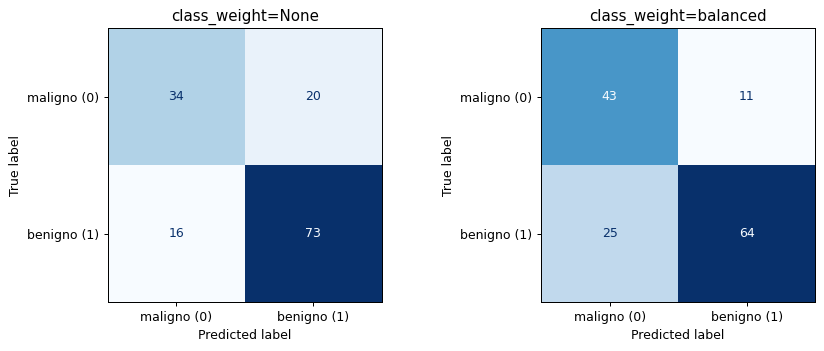

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, f1_score, fbeta_score

resultados = []
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, usar_cw in zip(axes, (False, True)):
    m, _, _ = entrenar_modelo(df, usar_class_weight=usar_cw)
    pred = m.predict(X_test)
    cm = confusion_matrix(y_test, pred, labels=[0, 1])
    vp, fn, fp, vn = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]   # positivo = maligno (0)
    nombre = 'balanced' if usar_cw else 'None'
    ConfusionMatrixDisplay(cm, display_labels=['maligno (0)', 'benigno (1)']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'class_weight={nombre}')
    # Métricas calculadas con scikit-learn y verificadas a mano contra la matriz
    prec = precision_score(y_test, pred, pos_label=0)
    rec = recall_score(y_test, pred, pos_label=0)
    f1 = f1_score(y_test, pred, pos_label=0)
    assert abs(prec - vp / (vp + fp)) < 1e-9 and abs(rec - vp / (vp + fn)) < 1e-9
    resultados.append({'class_weight': nombre, 'VP': vp, 'FN': fn, 'FP': fp, 'VN': vn,
                       'Precisión maligno': prec, 'Exhaustividad maligno': rec, 'F1 maligno': f1,
                       'F2 maligno': fbeta_score(y_test, pred, beta=2, pos_label=0),
                       'Accuracy': (vp + vn) / cm.sum()})
plt.tight_layout()
plt.show()
tabla_metricas = pd.DataFrame(resultados).round(4)
print(tabla_metricas.to_string(index=False))

**Justificación de la métrica prioritaria.** En este contexto los dos errores no cuestan lo mismo. Un **falso negativo** (un tumor maligno clasificado como benigno) significa que la paciente no se prioriza para revisión: el diagnóstico se retrasa y el cáncer puede avanzar, un costo clínico grave y a veces irreversible. Un **falso positivo** (un benigno marcado como maligno) cuesta tiempo del especialista y ansiedad para la paciente, pero se corrige en la revisión humana, que de todos modos es la decisión final. Por eso la métrica prioritaria es la **exhaustividad (recall) de la clase maligno**: la proporción de tumores malignos que el modelo no deja escapar. La precisión se vigila como restricción secundaria (si cae demasiado, el especialista se satura de falsas alarmas) y el F1 —o mejor el F2, que pondera más el recall— sirve para comparar modelos con un solo número. Con esta lógica se prefiere el modelo con `class_weight="balanced"`: con el mismo accuracy (0.7483), detecta 43 de 54 malignos frente a 34 de 54, a cambio de más falsos positivos. El accuracy por sí solo habría declarado un empate entre dos modelos clínicamente muy distintos.

### Peso de cada variable en el modelo

En regresión logística, cada coeficiente indica cuánto empuja esa variable hacia "benigno" o hacia "maligno". Una variable con un peso muchísimo mayor que las demás merece una segunda mirada.

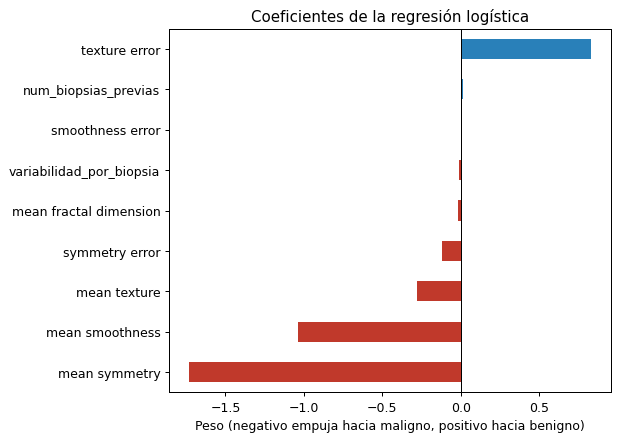

In [15]:
coeficientes = pd.Series(modelo.coef_[0], index=COLUMNAS_PREDICTORAS).sort_values()

plt.figure(figsize=(7, 5))
colores = ['#c0392b' if v < 0 else '#2980b9' for v in coeficientes]
coeficientes.plot(kind='barh', color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes de la regresión logística')
plt.xlabel('Peso (negativo empuja hacia maligno, positivo hacia benigno)')
plt.tight_layout()
plt.show()

## 7. Guardar el modelo entrenado

El equipo de infraestructura toma este archivo y lo despliega tal cual — así que necesita quedar en un estado entrenado y correcto.

In [16]:
def guardar_modelo(modelo, ruta="modelo_biopsias.joblib"):
    """Serializa el modelo entrenado para que el servicio de inferencia lo cargue."""
    joblib.dump(modelo, ruta)
    print(f"Modelo guardado en: {ruta}")


guardar_modelo(modelo)

Modelo guardado en: modelo_biopsias.joblib


## 8. Predecir un caso nuevo

Así es como el equipo clínico piensa usar la app: le pasan las mediciones de una paciente nueva y el modelo devuelve una predicción.

In [17]:
def predecir_caso(modelo, caso: dict):
    """Predice el diagnóstico para una paciente nueva a partir de un diccionario de mediciones."""
    entrada = pd.DataFrame([caso])[COLUMNAS_PREDICTORAS]
    pred = modelo.predict(entrada)[0]
    return 'benigno' if pred == 1 else 'maligno'


caso_nuevo = {
    'mean texture': 18.2,
    'mean smoothness': 0.095,
    'mean symmetry': 0.18,
    'mean fractal dimension': 0.062,
    'texture error': 1.1,
    'smoothness error': 0.006,
    'symmetry error': 0.02,
    'variabilidad_por_biopsia': 18.2,
    'num_biopsias_previas': 1,
}

predecir_caso(modelo, caso_nuevo)

'benigno'